In [2]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import tensorflow as tf 
from tensorflow import keras 
import matplotlib.pyplot as plt 
%matplotlib inline 
import numpy as np

In [3]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

In [4]:
len(X_train), len(X_test)

(60000, 10000)

In [5]:
X_train.shape

(60000, 28, 28)

In [6]:
X_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

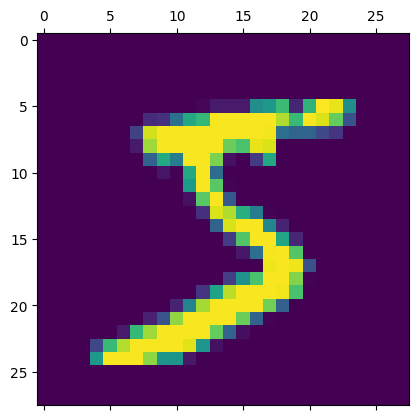

In [6]:
plt.matshow(X_train[0]) # matrix show

In [7]:
y_train[0]

np.uint8(5)

In [8]:
y_train[:5]

array([5, 0, 4, 1, 9], dtype=uint8)

In [4]:
X_train = X_train/255 # !important 
X_test = X_test/255

In [5]:
X_train_flattened = X_train.reshape(X_train.shape[0], 28 * 28 )
X_test_flattened = X_test.reshape(X_test.shape[0], 28 * 28 )

In [11]:
X_train_flattened.shape

(60000, 784)

In [14]:
X_train_flattened[0] # from 2d to 1d

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

1. NN

In [12]:
model = keras.Sequential([ # stack of neural networks 
    # output is 10 (maybe is the input of the next layer), intput node count = 784
    keras.layers.Dense(10, input_shape=(784, ), activation='sigmoid')
])

model.compile(optimizer='adam', 
              # sparse: because the output variable (y_label) is actually an integer number
              # if it is onehot encoded array => use categorical_crossentropy
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy']
)

model.fit(X_train_flattened, y_train, epochs = 5)

c:\Users\HuyenDT\source\repos\deeplearning\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8771 - loss: 0.4700
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9154 - loss: 0.3046
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9203 - loss: 0.2837
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9238 - loss: 0.2729
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9259 - loss: 0.2664


In [13]:
model.evaluate(X_test_flattened, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9232 - loss: 0.2702


[0.27024364471435547, 0.9232000112533569]

In [14]:
y_predicted = model.predict(X_test_flattened)
y_predicted[0] # probabilities for 10 classes

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 974us/step


array([2.6641479e-02, 3.6540197e-07, 5.5950046e-02, 9.5435667e-01,
       3.1096293e-03, 1.3377926e-01, 1.3426724e-06, 9.9984068e-01,
       7.1767025e-02, 7.1573550e-01], dtype=float32)

In [15]:
np.argmax(y_predicted[0])

np.int64(7)

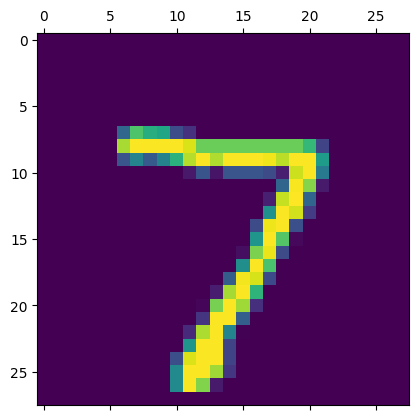

In [16]:
plt.matshow(X_test[0])

In [17]:
y_predicted_labels = [np.argmax(i) for i in y_predicted]


In [18]:
y_predicted_labels[:5]

[np.int64(7), np.int64(2), np.int64(1), np.int64(0), np.int64(4)]

In [19]:
y_test[:5]

array([7, 2, 1, 0, 4], dtype=uint8)

In [20]:
cm = tf.math.confusion_matrix(y_test, y_predicted_labels)
cm 

<tf.Tensor: shape=(10, 10), dtype=int32, numpy=
array([[ 963,    0,    2,    2,    0,    5,    5,    2,    1,    0],
       [   0, 1109,    3,    2,    1,    1,    4,    2,   13,    0],
       [   4,    6,  935,   16,    8,    5,   11,   10,   32,    5],
       [   2,    0,   22,  917,    0,   33,    2,   12,   10,   12],
       [   1,    1,    6,    1,  905,    0,    8,    4,    8,   48],
       [   8,    2,    5,   18,   11,  802,   12,    6,   21,    7],
       [  10,    3,    9,    1,    8,   22,  900,    2,    3,    0],
       [   1,    6,   23,    5,    6,    0,    0,  949,    1,   37],
       [   7,    7,    9,   30,    9,   44,    9,   13,  823,   23],
       [  11,    6,    1,    8,   21,    9,    0,   22,    2,  929]],
      dtype=int32)>

Text(95.72222222222221, 0.5, 'Truth')

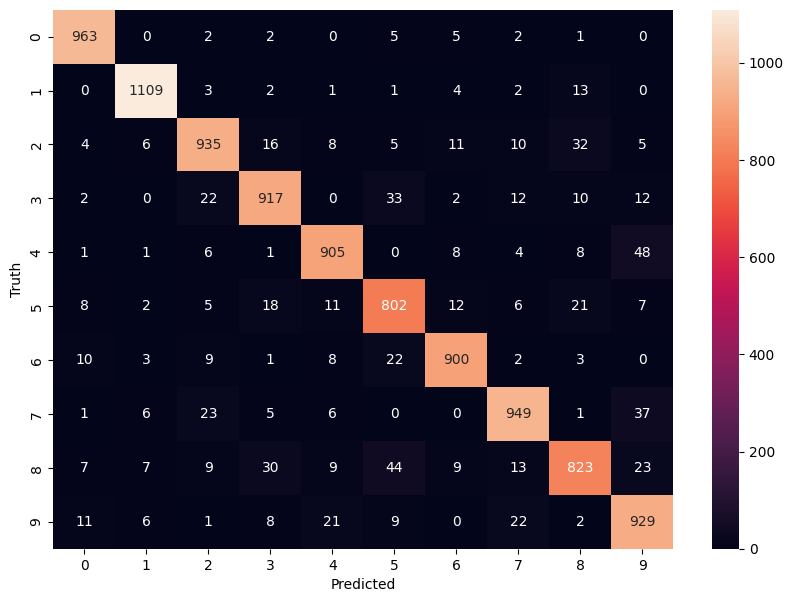

In [21]:
import seaborn as sns

plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d') # anything that is not in the diagonal is the error
plt.xlabel("Predicted")
plt.ylabel("Truth")

### 1.2 NN with more hidden layers

In [22]:
model = keras.Sequential([
    keras.layers.Dense(100, input_shape=(784, ), activation='relu'),
    keras.layers.Dense(10, activation='sigmoid') # adding more hidden layers tends to imporve the performance
])

model.compile(optimizer='adam', 
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy']
)

model.fit(X_train_flattened, y_train, epochs = 5)

c:\Users\HuyenDT\source\repos\deeplearning\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9226 - loss: 0.2715
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9640 - loss: 0.1232
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9742 - loss: 0.0855
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9800 - loss: 0.0654
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9841 - loss: 0.0513


In [23]:
model.evaluate(X_test_flattened, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9740 - loss: 0.0875


[0.08748425543308258, 0.9739999771118164]

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 967us/step


Text(95.72222222222221, 0.5, 'Truth')

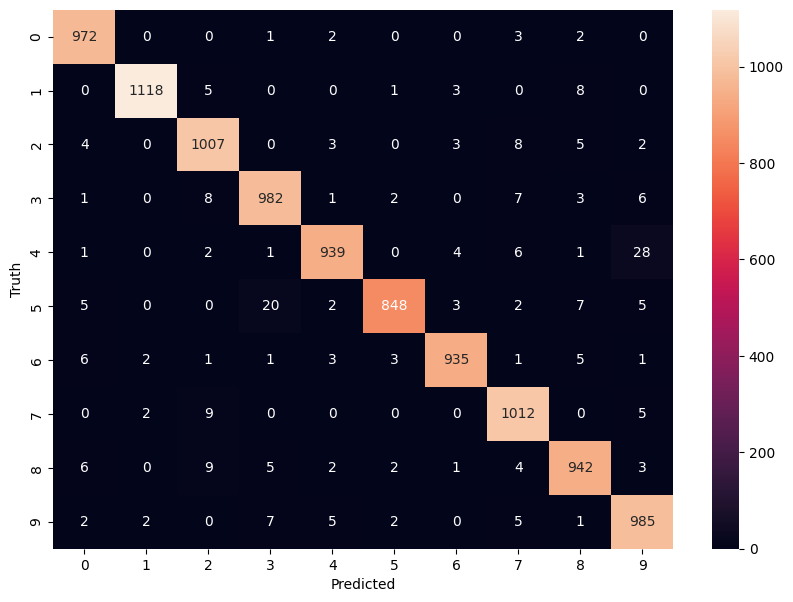

In [24]:
y_predicted = model.predict(X_test_flattened)
y_predicted_labels = [np.argmax(i) for i in y_predicted]
cm = tf.math.confusion_matrix(y_test, y_predicted_labels)

plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d') # anything that is not in the diagonal is the error
plt.xlabel("Predicted")
plt.ylabel("Truth")

### 1.3 NN with more hidden layers

In [20]:
# if don't want to flatten input before training => add Flatten layer
# add dropout layer (usually after every other layers => to reduce overfitting)
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28,28)),
    keras.layers.Dense(100, activation='relu'),  # in case, don't know what activation function to use, go with relu
    keras.layers.Dense(10, activation='sigmoid') # adding more hidden layers tends to imporve the performance
])

model.compile(
    optimizer='adam', 
    loss='sparse_categorical_crossentropy', # learning_rate usually = 0.01, w1 = w1 - learning rate.deriative(y(x1))
    metrics=['accuracy']
)

model.fit(X_train, y_train, epochs = 5)

Epoch 1/5
1875/1875 [==============================] - 6s 3ms/step - loss: 0.2683 - accuracy: 0.9218
Epoch 2/5
1875/1875 [==============================] - 3s 2ms/step - loss: 0.1191 - accuracy: 0.9644
Epoch 3/5
1875/1875 [==============================] - 3s 2ms/step - loss: 0.0843 - accuracy: 0.9746
Epoch 4/5
1875/1875 [==============================] - 4s 2ms/step - loss: 0.0654 - accuracy: 0.9799
Epoch 5/5
1875/1875 [==============================] - 3s 2ms/step - loss: 0.0509 - accuracy: 0.9842


In [21]:
model.evaluate(X_test, y_test)

313/313 [==============================] - 1s 1ms/step - loss: 0.0785 - accuracy: 0.9760


[0.0784950703382492, 0.9760000109672546]

In [22]:
y_predicted = model.predict(X_test)

313/313 [==============================] - 0s 1ms/step


In [53]:
model.save("./savedmodel/qt/my_model.keras")

### 2. Quantization and TFLite

2.1. Post Training Quantization

- Convert to Tf.lite

In [57]:
# Load model trước
model = tf.keras.models.load_model("./savedmodel/qt/my_model.keras")

# Truyền object, không phải string
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

print(len(tflite_model), "bytes")

c:\Users\HuyenDT\source\repos\deeplearning\.venv\Lib\site-packages\keras\src\saving\saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 6 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


INFO:tensorflow:Assets written to: C:\Users\HuyenDT\AppData\Local\Temp\tmpt711n3yx\assets


INFO:tensorflow:Assets written to: C:\Users\HuyenDT\AppData\Local\Temp\tmpt711n3yx\assets


Saved artifact at 'C:\Users\HuyenDT\AppData\Local\Temp\tmpt711n3yx'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 28, 28), dtype=tf.float32, name='input_layer_5')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  1643462278992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1643480996304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1643480993424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1643480990736: TensorSpec(shape=(), dtype=tf.resource, name=None)
320848 bytes


- Add quantization

In [ ]:
# Truyền object, không phải string
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT] # only quantize weights, not activations
tflite_quantized_model = converter.convert()
print(len(tflite_quantized_model), "bytes")

INFO:tensorflow:Assets written to: C:\Users\HuyenDT\AppData\Local\Temp\tmpya3dl5vt\assets


INFO:tensorflow:Assets written to: C:\Users\HuyenDT\AppData\Local\Temp\tmpya3dl5vt\assets


Saved artifact at 'C:\Users\HuyenDT\AppData\Local\Temp\tmpya3dl5vt'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 28, 28), dtype=tf.float32, name='input_layer_5')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  1643462278992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1643480996304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1643480993424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1643480990736: TensorSpec(shape=(), dtype=tf.resource, name=None)
86912 bytes


In [59]:
with open("outputs/tflite_model.tflite", "wb") as f:
    f.write(tflite_model)

with open("outputs/tflite_quantized_model.tflite", "wb") as f:
    f.write(tflite_quantized_model)

2.2. Quatization aware training

In [6]:
import tf_keras # legacy keras
import tensorflow_model_optimization as tfmot
# if don't want to flatten input before training => add Flatten layer
# add dropout layer (usually after every other layers => to reduce overfitting)
model = tf_keras.Sequential([
    tf_keras.layers.Flatten(input_shape=(28,28)),
    tf_keras.layers.Dense(100, activation='relu'),  # in case, don't know what activation function to use, go with relu
    tf_keras.layers.Dense(10, activation='sigmoid') # adding more hidden layers tends to imporve the performance
])

In [8]:
quantize_model = tfmot.quantization.keras.quantize_model
quantized_model = quantize_model(model)
quantized_model.compile(
    optimizer='adam', 
    loss='sparse_categorical_crossentropy', # learning_rate usually = 0.01, w1 = w1 - learning rate.deriative(y(x1))
    metrics=['accuracy']
)

quantized_model.fit(X_train, y_train, epochs = 5)

Epoch 1/5
1875/1875 [==============================] - 6s 3ms/step - loss: 0.0445 - accuracy: 0.9860
Epoch 2/5
1875/1875 [==============================] - 7s 3ms/step - loss: 0.0342 - accuracy: 0.9892
Epoch 3/5
1875/1875 [==============================] - 6s 3ms/step - loss: 0.0279 - accuracy: 0.9918
Epoch 4/5
1875/1875 [==============================] - 5s 3ms/step - loss: 0.0232 - accuracy: 0.9927
Epoch 5/5
1875/1875 [==============================] - 5s 3ms/step - loss: 0.0201 - accuracy: 0.9938


In [14]:
converter = tf.lite.TFLiteConverter.from_keras_model(quantized_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT] # only quantize weights, not activations
tflite_qat_model = converter.convert()
print(len(tflite_qat_model), "bytes")

INFO:tensorflow:Assets written to: C:\Users\HuyenDT\AppData\Local\Temp\tmpj38bfzfp\assets


INFO:tensorflow:Assets written to: C:\Users\HuyenDT\AppData\Local\Temp\tmpj38bfzfp\assets


82792 bytes


c:\Users\HuyenDT\source\repos\deeplearning\.venv\Lib\site-packages\tensorflow\lite\python\convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


In [15]:
with open("outputs/tflite_qat_model.tflite", "wb") as f:
    f.write(tflite_qat_model)

### 3. CNN

In [28]:
X_train.shape


(60000, 28, 28)

In [29]:
cnn = keras.Sequential([
    #cnn
    keras.layers.Conv2D(input_shape=(28,28,1), filters =32, kernel_size=(3,3), activation='relu'),
    keras.layers.MaxPooling2D((2,2)),
    #dense
    keras.layers.Flatten(),
    keras.layers.Dense(100, activation='relu'),  # in case, don't know what activation function to use, go with relu
    keras.layers.Dense(10, activation='softmax') # adding more hidden layers tends to imporve the performance
])

cnn.compile(
    optimizer='adam', 
    loss='sparse_categorical_crossentropy', # learning_rate usually = 0.01, w1 = w1 - learning rate.deriative(y(x1))
    metrics=['accuracy']
)

cnn.fit(X_train, y_train, epochs = 5)

c:\Users\HuyenDT\source\repos\deeplearning\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9537 - loss: 0.1562
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9834 - loss: 0.0534
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9888 - loss: 0.0361
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9925 - loss: 0.0243
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9942 - loss: 0.0177


In [30]:
cnn.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9858 - loss: 0.0445


[0.0445389598608017, 0.98580002784729]